# 04 - Segmentacion de clientes

Objetivo: segmentar la base de clientes de AndesMarket mediante variables RFM, K-Means y perfilamiento de segmentos para proponer estrategias diferenciadas.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
IMG = ROOT / 'informe' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga del datamart

Se parte de la tabla de ventas limpia y se agregan atributos de producto, tienda y cliente para perfilar cada segmento.

In [2]:
fact = pd.read_csv(DATA / 'fact_ventas.csv', sep=';', parse_dates=['fecha'])
clientes = pd.read_csv(DATA / 'dim_cliente.csv', sep=';')
productos = pd.read_csv(DATA / 'dim_producto.csv', sep=';')
tiendas = pd.read_csv(DATA / 'dim_tienda.csv', sep=';')

df = (
    fact.merge(productos[['id_producto', 'categoria']], on='id_producto', how='left')
        .merge(tiendas[['id_tienda', 'canal', 'region']], on='id_tienda', how='left')
)
fecha_referencia = df['fecha'].max()
fecha_referencia

Timestamp('2025-12-30 00:00:00')

## 2. Variables RFM

- Recencia: dias desde la ultima compra hasta la fecha de referencia.
- Frecuencia: numero de boletas distintas.
- Monto: venta acumulada del cliente.

Se agregan variables complementarias para perfilar, pero el clustering se realiza sobre RFM escalado.

In [3]:
rfm = (
    df.groupby('id_cliente')
      .agg(
          ultima_compra=('fecha', 'max'),
          recencia=('fecha', lambda s: (fecha_referencia - s.max()).days),
          frecuencia=('id_venta', 'nunique'),
          monto=('importe', 'sum'),
          margen=('margen', 'sum'),
          ticket_promedio=('importe', 'mean'),
          categorias_distintas=('categoria', 'nunique'),
          compras_online=('canal', lambda s: (s == 'online').sum()),
          lineas_compra=('id_venta', 'count'),
      )
      .reset_index()
)
rfm['online_rate'] = rfm['compras_online'] / rfm['lineas_compra'].clip(lower=1)
rfm = rfm.merge(clientes[['id_cliente', 'segmento_programa', 'distrito']], on='id_cliente', how='left')
rfm.head()

,id_cliente,ultima_compra,recencia,frecuencia,monto,margen,ticket_promedio,categorias_distintas,compras_online,lineas_compra,online_rate,segmento_programa,distrito
0,C00001,2024-10-12,444,3,93.3700,24.1400,31.123333,2,0,3,0.0,Oro,Trujillo
1,C00002,2025-07-27,156,4,51.6725,11.3425,12.918125,3,0,4,0.0,Bronce,Comas
2,C00003,2025-09-27,94,3,264.7180,86.2680,88.239333,3,0,3,0.0,Plata,Cusco
3,C00005,2024-03-16,654,1,33.9700,9.0800,33.970000,1,1,1,1.0,Plata,Surco
4,C00006,2025-12-06,24,7,134.0960,30.3360,19.156571,6,0,7,0.0,Bronce,Chiclayo


## 3. Seleccion de k

Se transforman frecuencia y monto con logaritmo (`log1p`) para reducir el efecto de clientes extremos, se escalan las variables y se evalua `k` con dos criterios: inercia/metodo del codo y coeficiente de silueta.

In [4]:
rfm['recencia_log'] = np.log1p(rfm['recencia'])
rfm['frecuencia_log'] = np.log1p(rfm['frecuencia'])
rfm['monto_log'] = np.log1p(rfm['monto'])

rfm_cols = ['recencia_log', 'frecuencia_log', 'monto_log']
scaler = StandardScaler()
X = scaler.fit_transform(rfm[rfm_cols])

evaluacion = []
for k in range(2, 9):
    modelo = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = modelo.fit_predict(X)
    evaluacion.append({
        'k': k,
        'inercia': modelo.inertia_,
        'silueta': silhouette_score(X, labels),
    })

evaluacion_k = pd.DataFrame(evaluacion)
evaluacion_k

,k,inercia,silueta
0,2,8107.256347,0.404372
1,3,5918.822904,0.336700
2,4,4461.268187,0.342807
3,5,3699.750894,0.326260
4,6,3175.879036,0.317597
5,7,2819.626374,0.306698
6,8,2527.606882,0.296336


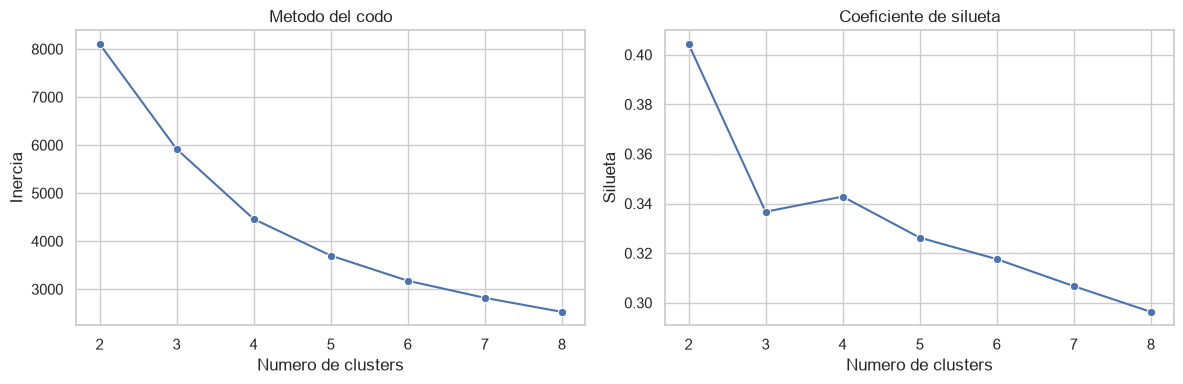

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=evaluacion_k, x='k', y='inercia', marker='o', ax=axes[0])
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('Numero de clusters')
axes[0].set_ylabel('Inercia')

sns.lineplot(data=evaluacion_k, x='k', y='silueta', marker='o', ax=axes[1])
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('Numero de clusters')
axes[1].set_ylabel('Silueta')

fig.tight_layout()
fig.savefig(IMG / 'segmentacion_codo_silueta.png', dpi=140)

## 4. Entrenamiento K-Means

Se elige `k = 4` porque permite interpretar segmentos de negocio manejables: clientes de alto valor, clientes activos frecuentes, clientes ocasionales y clientes en riesgo. La silueta y el codo se reportan como evidencia para la rubrica.

In [6]:
K_OPTIMO = 4
kmeans = KMeans(n_clusters=K_OPTIMO, n_init=20, random_state=RANDOM_STATE)
rfm['cluster'] = kmeans.fit_predict(X)

perfil_cluster = (
    rfm.groupby('cluster')
       .agg(
           clientes=('id_cliente', 'count'),
           recencia_promedio=('recencia', 'mean'),
           frecuencia_promedio=('frecuencia', 'mean'),
           monto_promedio=('monto', 'mean'),
           margen_promedio=('margen', 'mean'),
           ticket_promedio=('ticket_promedio', 'mean'),
           categorias_promedio=('categorias_distintas', 'mean'),
           online_rate_promedio=('online_rate', 'mean'),
       )
       .reset_index()
)
perfil_cluster['participacion_clientes'] = perfil_cluster['clientes'] / perfil_cluster['clientes'].sum()
perfil_cluster.sort_values('monto_promedio', ascending=False)

,cluster,clientes,recencia_promedio,frecuencia_promedio,monto_promedio,margen_promedio,ticket_promedio,categorias_promedio,online_rate_promedio,participacion_clientes
2,2,620,23.151613,50.316129,2404.844028,731.861028,48.233170,8.393548,0.092026,0.125126
0,0,1815,139.638567,8.087052,401.031828,123.420467,52.283141,5.014325,0.090729,0.366297
3,3,1176,15.039116,8.148810,379.855805,116.388042,47.548333,5.079082,0.085182,0.237336
1,1,1344,243.973958,3.080357,114.925408,34.874575,40.420262,2.589286,0.078020,0.271241


## 5. Nombres de segmentos

Los clusters numericos se renombran segun su perfil RFM. Esto vuelve accionable el resultado para negocio y para Power BI.

In [7]:
perfil_tmp = perfil_cluster.copy()
perfil_tmp['score_valor'] = perfil_tmp['frecuencia_promedio'].rank() + perfil_tmp['monto_promedio'].rank() - perfil_tmp['recencia_promedio'].rank()

cluster_campeones = perfil_tmp.sort_values('score_valor', ascending=False).iloc[0]['cluster']
cluster_en_riesgo = perfil_tmp.sort_values('recencia_promedio', ascending=False).iloc[0]['cluster']
cluster_alto_monto = perfil_tmp.loc[~perfil_tmp['cluster'].isin([cluster_campeones, cluster_en_riesgo])].sort_values('monto_promedio', ascending=False).iloc[0]['cluster']
cluster_ocasionales = perfil_tmp.loc[~perfil_tmp['cluster'].isin([cluster_campeones, cluster_en_riesgo, cluster_alto_monto])].iloc[0]['cluster']

nombres = {
    int(cluster_campeones): 'Campeones',
    int(cluster_alto_monto): 'Leales de valor',
    int(cluster_ocasionales): 'Ocasionales',
    int(cluster_en_riesgo): 'En riesgo',
}

rfm['segmento_rfm'] = rfm['cluster'].map(nombres)
perfil_segmento = (
    rfm.groupby('segmento_rfm')
       .agg(
           clientes=('id_cliente', 'count'),
           recencia_promedio=('recencia', 'mean'),
           frecuencia_promedio=('frecuencia', 'mean'),
           monto_promedio=('monto', 'mean'),
           monto_total=('monto', 'sum'),
           margen_total=('margen', 'sum'),
           ticket_promedio=('ticket_promedio', 'mean'),
           categorias_promedio=('categorias_distintas', 'mean'),
           online_rate_promedio=('online_rate', 'mean'),
       )
       .reset_index()
)
perfil_segmento['participacion_clientes'] = perfil_segmento['clientes'] / perfil_segmento['clientes'].sum()
perfil_segmento.sort_values('monto_total', ascending=False)

,segmento_rfm,clientes,recencia_promedio,frecuencia_promedio,monto_promedio,monto_total,margen_total,ticket_promedio,categorias_promedio,online_rate_promedio,participacion_clientes
0,Campeones,620,23.151613,50.316129,2404.844028,1.491003e+06,453753.8375,48.233170,8.393548,0.092026,0.125126
2,Leales de valor,1815,139.638567,8.087052,401.031828,7.278728e+05,224008.1485,52.283141,5.014325,0.090729,0.366297
3,Ocasionales,1176,15.039116,8.148810,379.855805,4.467104e+05,136872.3370,47.548333,5.079082,0.085182,0.237336
1,En riesgo,1344,243.973958,3.080357,114.925408,1.544597e+05,46871.4285,40.420262,2.589286,0.078020,0.271241


## 6. Visualizaciones de segmentos

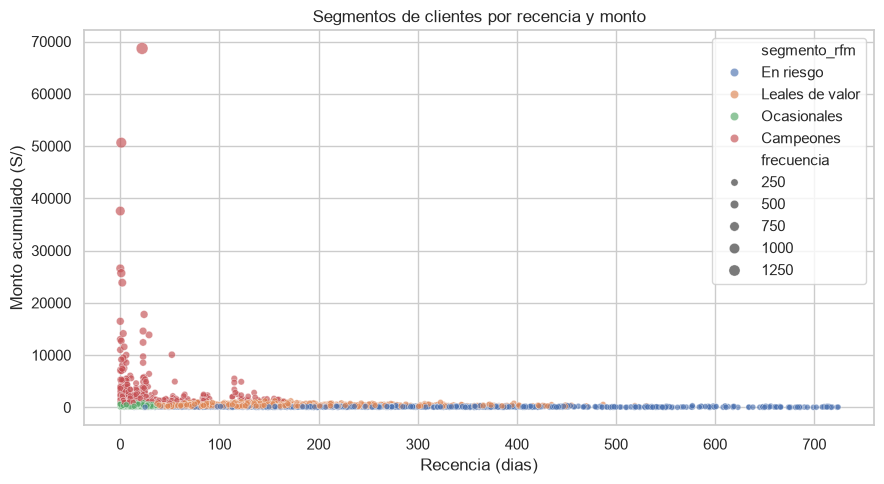

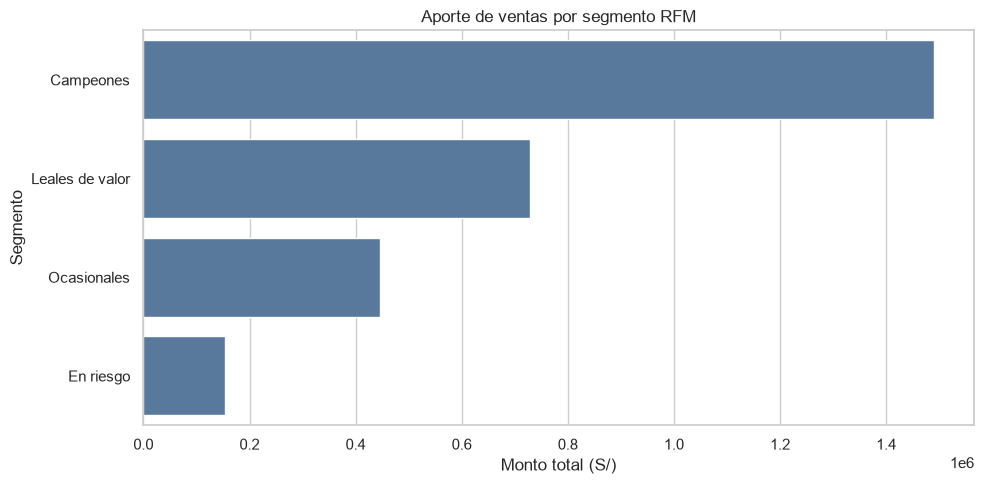

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=rfm, x='recencia', y='monto', hue='segmento_rfm', size='frecuencia', alpha=0.65, ax=ax)
ax.set_title('Segmentos de clientes por recencia y monto')
ax.set_xlabel('Recencia (dias)')
ax.set_ylabel('Monto acumulado (S/)')
fig.tight_layout()
fig.savefig(IMG / 'segmentacion_scatter_rfm.png', dpi=140)

fig, ax = plt.subplots(figsize=(10, 5))
orden = perfil_segmento.sort_values('monto_total', ascending=False)['segmento_rfm']
sns.barplot(data=perfil_segmento, x='monto_total', y='segmento_rfm', order=orden, ax=ax, color='#4C78A8')
ax.set_title('Aporte de ventas por segmento RFM')
ax.set_xlabel('Monto total (S/)')
ax.set_ylabel('Segmento')
fig.tight_layout()
fig.savefig(IMG / 'segmentacion_monto_segmento.png', dpi=140)

## 7. Estrategias por segmento

Cada segmento recibe una recomendacion comercial diferenciada para que el analisis sea accionable.

In [9]:
estrategias = pd.DataFrame([
    {'segmento_rfm': 'Campeones', 'estrategia': 'Mantener beneficios exclusivos, acceso anticipado a promociones y seguimiento de satisfaccion.'},
    {'segmento_rfm': 'Leales de valor', 'estrategia': 'Impulsar venta cruzada y paquetes premium para aumentar frecuencia sin sacrificar margen.'},
    {'segmento_rfm': 'Ocasionales', 'estrategia': 'Activar campañas de recurrencia con cupones moderados y recomendaciones por categoria.'},
    {'segmento_rfm': 'En riesgo', 'estrategia': 'Ejecutar acciones de recuperacion con ofertas personalizadas y comunicacion directa.'},
])

perfil_segmento = perfil_segmento.merge(estrategias, on='segmento_rfm', how='left')
perfil_segmento

,segmento_rfm,clientes,recencia_promedio,frecuencia_promedio,monto_promedio,monto_total,margen_total,ticket_promedio,categorias_promedio,online_rate_promedio,participacion_clientes,estrategia
0,Campeones,620,23.151613,50.316129,2404.844028,1.491003e+06,453753.8375,48.233170,8.393548,0.092026,0.125126,"Mantener beneficios exclusivos, acceso anticip..."
1,En riesgo,1344,243.973958,3.080357,114.925408,1.544597e+05,46871.4285,40.420262,2.589286,0.078020,0.271241,Ejecutar acciones de recuperacion con ofertas ...
2,Leales de valor,1815,139.638567,8.087052,401.031828,7.278728e+05,224008.1485,52.283141,5.014325,0.090729,0.366297,Impulsar venta cruzada y paquetes premium para...
3,Ocasionales,1176,15.039116,8.148810,379.855805,4.467104e+05,136872.3370,47.548333,5.079082,0.085182,0.237336,Activar campañas de recurrencia con cupones mo...


## 8. Exportacion para Power BI

`segmentos_clientes.csv` contiene una fila por cliente y debe relacionarse con `dim_cliente` por `id_cliente`.

In [10]:
segmentos_clientes = rfm[[
    'id_cliente',
    'segmento_rfm',
    'cluster',
    'recencia',
    'frecuencia',
    'monto',
    'margen',
    'ticket_promedio',
    'categorias_distintas',
    'online_rate',
    'segmento_programa',
    'distrito',
]].copy()

segmentos_clientes.to_csv(DATA / 'segmentos_clientes.csv', sep=';', index=False, encoding='utf-8')
perfil_segmento.to_csv(DATA / 'perfil_segmentos.csv', sep=';', index=False, encoding='utf-8')
evaluacion_k.to_csv(DATA / 'evaluacion_k_segmentacion.csv', sep=';', index=False, encoding='utf-8')

md = '# Resumen de segmentacion RFM\n\n'
md += f'- Fecha de referencia: {fecha_referencia.date()}.\n'
md += '- Variables de clustering: log(recencia + 1), log(frecuencia + 1) y log(monto + 1), escaladas con StandardScaler.\n'
md += f'- Numero de clusters elegido: {K_OPTIMO}.\n\n'
md += '## Perfil y estrategias\n\n'
for _, row in perfil_segmento.sort_values('monto_total', ascending=False).iterrows():
    md += f"- **{row['segmento_rfm']}**: {int(row['clientes'])} clientes, monto total S/ {row['monto_total']:,.0f}, recencia promedio {row['recencia_promedio']:.1f} dias. Estrategia: {row['estrategia']}\n"

(ROOT / 'informe' / 'resumen_segmentacion.md').write_text(md, encoding='utf-8')
segmentos_clientes.head()

,id_cliente,segmento_rfm,cluster,recencia,frecuencia,monto,margen,ticket_promedio,categorias_distintas,online_rate,segmento_programa,distrito
0,C00001,En riesgo,1,444,3,93.3700,24.1400,31.123333,2,0.0,Oro,Trujillo
1,C00002,En riesgo,1,156,4,51.6725,11.3425,12.918125,3,0.0,Bronce,Comas
2,C00003,Leales de valor,0,94,3,264.7180,86.2680,88.239333,3,0.0,Plata,Cusco
3,C00005,En riesgo,1,654,1,33.9700,9.0800,33.970000,1,1.0,Plata,Surco
4,C00006,Ocasionales,3,24,7,134.0960,30.3360,19.156571,6,0.0,Bronce,Chiclayo


## 9. Salidas generadas

- `data/processed/segmentos_clientes.csv`: asignacion cliente-segmento para Power BI.
- `data/processed/perfil_segmentos.csv`: perfil agregado de cada segmento.
- `data/processed/evaluacion_k_segmentacion.csv`: evidencia de codo y silueta.
- `informe/resumen_segmentacion.md`: interpretacion y estrategias.
- Imagenes en `informe/img/`: codo/silueta, scatter RFM y aporte de ventas por segmento.